In [ ]:
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

In [4]:
"""
cluster_mo_bigram.py
基于行为链 Bigram 共现特征的无监督诈骗类型聚类
"""

import pandas as pd
import numpy as np
import re
import json
import os
import warnings
warnings.filterwarnings("ignore")

import umap
import hdbscan
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import normalize

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import seaborn as sns

# 中文字体设置
for font in ["Arial Unicode MS", "SimHei", "PingFang SC", "Microsoft YaHei", "WenQuanYi Micro Hei"]:
    try:
        matplotlib.rcParams["font.sans-serif"] = [font]
        break
    except:
        continue
matplotlib.rcParams["axes.unicode_minus"] = False

# ================= 1. 配置 =================
INPUT_FILE = "/Users/syx/Desktop/5508/副本news_mo_cleaned_v3.xlsx"
OUTPUT_DIR = "/Users/syx/Desktop/5508/clustering_results_bigram_cleaned"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# 特征权重
UNIGRAM_WEIGHT = 1.0      # 单标签特征权重
BIGRAM_WEIGHT = 0.8        # 行为链 bigram 特征权重
MIN_BIGRAM_FREQ = 2        # bigram 至少出现2次才纳入特征

# ================= 2. 标签体系 =================
LABEL_DEFS = {
    "prep": [
        "PREP1_人设身份伪造", "PREP2_平台网站搭建",
        "PREP3_数据名单获取", "PREP4_无明显前期准备"
    ],
    "contact": [
        "CON1_盲发广撒触达", "CON2_社交平台搭讪",
        "CON3_需求场景切入", "CON4_冒名定向联络",
        "CON5_线下物理接触", "CON6_受害者主动上门"
    ],
    "trust": [
        "TRU1_公权身份伪装", "TRU2_机构品牌冒用",
        "TRU3_熟人关系利用", "TRU4_专业人设包装",
        "TRU5_群体氛围伪造", "TRU6_小额返利验证",
        "TRU7_伪造凭证文件"
    ],
    "manipulation": [
        "MAN1_恐吓威胁施压", "MAN2_高收益利诱",
        "MAN3_情感绑架操控", "MAN4_制造紧急时限",
        "MAN5_隔离保密要求", "MAN6_沉没成本追加"
    ],
    "operation": [
        "OPR1_下载安装应用", "OPR2_共享屏幕远程控制",
        "OPR3_点击链接填写信息", "OPR4_注册账户加入群组",
        "OPR5_执行刷单任务", "OPR6_上传证件人脸识别"
    ],
    "extraction": [
        "EXT1_银行转账", "EXT2_第三方数字支付",
        "EXT3_加密货币转移", "EXT4_礼品卡充值卡",
        "EXT5_线下现金交割", "EXT6_账户权限接管"
    ],
    "aftermath": [
        "AFT1_立即失联消失", "AFT2_设障拖延拒付",
        "AFT3_编造新由追骗", "AFT4_转化身份复害",
        "AFT5_转为勒索威胁", "AFT6_发展为工具人"
    ],
}

ALL_UNIGRAM_LABELS = []
for dim, labels in LABEL_DEFS.items():
    ALL_UNIGRAM_LABELS.extend(labels)

# ================= 3. 辅助函数 =================

def extract_prefix(full_label):
    """从完整标签提取前缀代码，如 'PREP1_人设身份伪造' → 'PREP1'"""
    match = re.match(r'^([A-Z]+\d+)', str(full_label))
    return match.group(1) if match else None


def parse_sequence(seq_str):
    """
    解析 scene_sequence 字符串为标签列表。
    支持格式：'A → B → C' 或 '["A", "B", "C"]'
    """
    if pd.isna(seq_str) or str(seq_str).strip() in ["", "不适用", "nan"]:
        return []

    s = str(seq_str).strip()

    # 尝试 JSON 列表格式
    if s.startswith("["):
        try:
            lst = json.loads(s)
            return [str(x).strip() for x in lst if str(x).strip()]
        except:
            pass

    # 箭头分隔格式
    if "→" in s:
        return [x.strip() for x in s.split("→") if x.strip()]

    # 逗号分隔
    if "," in s:
        return [x.strip() for x in s.split(",") if x.strip()]

    return [s] if s else []


def extract_bigrams(seq_list):
    """从标签序列中提取所有相邻 bigram 对（使用前缀代码）"""
    prefixes = []
    for label in seq_list:
        p = extract_prefix(label)
        if p:
            prefixes.append(p)

    bigrams = []
    for i in range(len(prefixes) - 1):
        bigram = f"{prefixes[i]}→{prefixes[i+1]}"
        bigrams.append(bigram)

    return bigrams


def encode_unigram(row):
    """编码 primary/secondary 标签为 multi-hot 向量"""
    vec = np.zeros(len(ALL_UNIGRAM_LABELS), dtype=np.float32)

    for dim in LABEL_DEFS:
        primary = str(row.get(f"{dim}_primary", "")).strip()
        secondary = str(row.get(f"{dim}_secondary", "")).strip()

        if primary in ALL_UNIGRAM_LABELS:
            idx = ALL_UNIGRAM_LABELS.index(primary)
            vec[idx] = 1.0

        if secondary in ALL_UNIGRAM_LABELS:
            idx = ALL_UNIGRAM_LABELS.index(secondary)
            vec[idx] = max(vec[idx], 0.5)

    return vec


# ================= 4. 加载与预处理 =================
print("=" * 60)
print("  FRAUD MO CLUSTERING — BIGRAM CO-OCCURRENCE")
print("=" * 60)

print("\n📂 加载数据...")
df = pd.read_excel(INPUT_FILE)

df["is_scam"] = df["is_scam"].apply(
    lambda x: str(x).strip().lower() in ["true", "1", "yes"]
)

mask = (df["is_scam"] == True) & (df["detail_quality"].isin(["高", "中"]))
df_work = df[mask].copy()
print(f"   总数据: {len(df)} | 诈骗: {df['is_scam'].sum()} | 可聚类(高/中): {len(df_work)}")

if len(df_work) < 30:
    print("❌ 有效样本不足30条，无法聚类。")
    exit()

# ================= 5. 提取所有 Bigram =================
print("\n🔗 提取行为链 Bigram...")

all_bigrams_per_row = []
bigram_counter = {}

for idx, row in df_work.iterrows():
    seq = parse_sequence(row.get("scene_sequence", ""))
    bgs = extract_bigrams(seq)
    all_bigrams_per_row.append((idx, bgs))
    for bg in bgs:
        bigram_counter[bg] = bigram_counter.get(bg, 0) + 1

# 筛选高频 bigram（至少出现 MIN_BIGRAM_FREQ 次）
valid_bigrams = sorted([
    bg for bg, cnt in bigram_counter.items()
    if cnt >= MIN_BIGRAM_FREQ
])

print(f"   原始 bigram 种类: {len(bigram_counter)}")
print(f"   筛选后 (≥{MIN_BIGRAM_FREQ}次): {len(valid_bigrams)}")
print(f"\n   Top 20 Bigram:")
for bg, cnt in sorted(bigram_counter.items(), key=lambda x: -x[1])[:20]:
    print(f"     {bg}: {cnt}")

if len(valid_bigrams) == 0:
    print("⚠️ 没有有效 bigram，将仅使用 unigram 特征")

# ================= 6. 构建混合特征矩阵 =================
print("\n🔢 构建混合特征矩阵 (Unigram + Bigram)...")

X_uni_list = []
X_bi_list = []
valid_indices = []

for orig_idx, bigrams in all_bigrams_per_row:
    row = df_work.loc[orig_idx]

    # Unigram 编码
    uni_vec = encode_unigram(row)

    # Bigram 编码
    bi_vec = np.zeros(len(valid_bigrams), dtype=np.float32)
    for bg in bigrams:
        if bg in valid_bigrams:
            bi_idx = valid_bigrams.index(bg)
            bi_vec[bi_idx] = 1.0

    # 至少有一个非零特征
    if uni_vec.sum() > 0 or bi_vec.sum() > 0:
        X_uni_list.append(uni_vec)
        X_bi_list.append(bi_vec)
        valid_indices.append(orig_idx)

X_uni = np.array(X_uni_list)
X_bi = np.array(X_bi_list)

print(f"   Unigram 矩阵: {X_uni.shape}")
print(f"   Bigram 矩阵: {X_bi.shape}")

# 去除全零列
uni_used = X_uni.sum(axis=0) > 0
bi_used = X_bi.sum(axis=0) > 0 if X_bi.shape[1] > 0 else np.array([], dtype=bool)

X_uni_clean = X_uni[:, uni_used]
X_bi_clean = X_bi[:, bi_used] if bi_used.any() else np.zeros((len(X_uni), 0))

uni_labels_clean = [ALL_UNIGRAM_LABELS[i] for i in range(len(ALL_UNIGRAM_LABELS)) if uni_used[i]]
bi_labels_clean = [valid_bigrams[i] for i in range(len(valid_bigrams)) if bi_used[i]]

print(f"   清洗后 Unigram: {X_uni_clean.shape[1]} | Bigram: {X_bi_clean.shape[1]}")

# 加权拼接
if X_bi_clean.shape[1] > 0:
    # L2 归一化各部分，再加权拼接
    X_uni_norm = normalize(X_uni_clean, norm="l2") * UNIGRAM_WEIGHT
    X_bi_norm = normalize(X_bi_clean, norm="l2") * BIGRAM_WEIGHT
    X_combined = np.hstack([X_uni_norm, X_bi_norm])
    all_feature_names = uni_labels_clean + bi_labels_clean
else:
    X_combined = normalize(X_uni_clean, norm="l2")
    all_feature_names = uni_labels_clean

print(f"   最终特征矩阵: {X_combined.shape[0]} 样本 × {X_combined.shape[1]} 特征")

# 构建工作 DataFrame
df_cluster = df.loc[valid_indices].copy().reset_index(drop=True)

# ================= 7. UMAP 降维 =================
print("\n📐 UMAP 降维...")

n_neighbors = min(15, X_combined.shape[0] - 1)
n_comp_cluster = min(15, X_combined.shape[1] - 1, X_combined.shape[0] - 2)

umap_cluster = umap.UMAP(
    n_components=max(2, n_comp_cluster),
    n_neighbors=n_neighbors,
    min_dist=0.0,
    metric="cosine",
    random_state=42,
)
X_umap_high = umap_cluster.fit_transform(X_combined)
print(f"   聚类用嵌入: {X_umap_high.shape}")

umap_2d = umap.UMAP(
    n_components=2,
    n_neighbors=n_neighbors,
    min_dist=0.1,
    metric="cosine",
    random_state=42,
)
X_2d = umap_2d.fit_transform(X_combined)
df_cluster["umap_x"] = X_2d[:, 0]
df_cluster["umap_y"] = X_2d[:, 1]

# ================= 8. HDBSCAN 聚类 =================
print("\n🔬 HDBSCAN 聚类...")

min_cs = max(8, int(len(X_umap_high) * 0.02))
min_samp = max(3, int(min_cs * 0.5))
print(f"   参数: min_cluster_size={min_cs}, min_samples={min_samp}")

clusterer = hdbscan.HDBSCAN(
    min_cluster_size=min_cs,
    min_samples=min_samp,
    metric="euclidean",
    cluster_selection_method="eom",
    prediction_data=True,
)
labels = clusterer.fit_predict(X_umap_high)

df_cluster["cluster"] = labels
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = (labels == -1).sum()
print(f"   聚类数量: {n_clusters}")
print(f"   噪声点: {n_noise} ({n_noise / len(labels) * 100:.1f}%)")

if n_clusters >= 2:
    valid_mask = labels != -1
    if valid_mask.sum() > n_clusters:
        sil = silhouette_score(X_umap_high[valid_mask], labels[valid_mask])
        print(f"   Silhouette Score: {sil:.3f}")

# ================= 9. 聚类画像 =================
print("\n" + "=" * 70)
print("📋 聚类画像")
print("=" * 70)

profiles = []

for cid in sorted(set(labels) - {-1}):
    cmask = df_cluster["cluster"] == cid
    c_df = df_cluster[cmask]
    c_X_bi = X_bi_clean[cmask.values] if X_bi_clean.shape[1] > 0 else None

    profile = {"cluster_id": cid, "size": len(c_df)}

    # — MO 维度主标签统计 —
    canonical_steps = []
    for dim in LABEL_DEFS:
        col = f"{dim}_primary"
        if col in c_df.columns:
            counts = c_df[col].value_counts()
            if len(counts) > 0:
                profile[f"{dim}_dominant"] = counts.index[0]
                profile[f"{dim}_pct"] = f"{counts.iloc[0] / len(c_df) * 100:.0f}%"
                top = counts.index[0]
                if "未提及" not in str(top) and "不适用" not in str(top):
                    canonical_steps.append(str(top))

    profile["canonical_script"] = " → ".join(canonical_steps)

    # — Top Bigram 统计 —
    if c_X_bi is not None and c_X_bi.shape[1] > 0:
        mean_bi = c_X_bi.mean(axis=0)
        top_bi_indices = np.argsort(mean_bi)[::-1][:5]
        top_bigrams_str = []
        for i in top_bi_indices:
            if mean_bi[i] > 0:
                top_bigrams_str.append(f"{bi_labels_clean[i]}({mean_bi[i]*100:.0f}%)")
        profile["top_bigrams"] = " | ".join(top_bigrams_str)
    else:
        profile["top_bigrams"] = "N/A"

    # — 辅助字段 —
    for col_name in ["surface_scenario", "psychological_vulnerability", "compliance_driver"]:
        if col_name in c_df.columns:
            vc = c_df[col_name].value_counts()
            if len(vc) > 0:
                profile[f"top_{col_name}"] = vc.index[0]
                profile[f"top_{col_name}_pct"] = f"{vc.iloc[0] / len(c_df) * 100:.0f}%"

    # — 代表性案例摘要 (供LLM命名用) —
    sample_summaries = []
    if "script_track_summary" in c_df.columns:
        summaries = c_df["script_track_summary"].dropna()
        for s in summaries.head(5):
            if str(s).strip() not in ["", "不适用", "nan"]:
                sample_summaries.append(str(s).strip())
    profile["sample_summaries"] = " /// ".join(sample_summaries)

    # — 代表性 scene_sequence —
    sample_seqs = []
    if "scene_sequence" in c_df.columns:
        seqs = c_df["scene_sequence"].dropna()
        for s in seqs.head(5):
            if str(s).strip() not in ["", "不适用", "nan"]:
                sample_seqs.append(str(s).strip())
    profile["sample_sequences"] = " /// ".join(sample_seqs)

    profiles.append(profile)

    # 打印
    print(f"\n{'─' * 55}")
    print(f"  Cluster {cid}  |  n={len(c_df)}")
    print(f"{'─' * 55}")
    print(f"  典型脚本: {profile.get('canonical_script', '')}")
    print(f"  热门Bigram: {profile.get('top_bigrams', '')}")
    print(f"  场景: {profile.get('top_surface_scenario', '')} ({profile.get('top_surface_scenario_pct', '')})")
    print(f"  心理: {profile.get('top_psychological_vulnerability', '')}")
    print(f"  驱动: {profile.get('top_compliance_driver', '')}")
    for dim in LABEL_DEFS:
        print(f"    {dim:15s}: {profile.get(f'{dim}_dominant', 'N/A')} ({profile.get(f'{dim}_pct', '')})")

profile_df = pd.DataFrame(profiles)

# ================= 10. 可视化 =================
print("\n📊 生成可视化...")

# 图1: UMAP 散点图
fig1, ax1 = plt.subplots(figsize=(14, 10))
noise_mask = df_cluster["cluster"] == -1
if noise_mask.any():
    ax1.scatter(
        df_cluster.loc[noise_mask, "umap_x"],
        df_cluster.loc[noise_mask, "umap_y"],
        c="lightgray", s=8, alpha=0.3, label="Noise", zorder=1
    )
cmap_c = plt.cm.get_cmap("tab20", max(n_clusters, 1))
for i, cid in enumerate(sorted(set(labels) - {-1})):
    cmask = df_cluster["cluster"] == cid
    ax1.scatter(
        df_cluster.loc[cmask, "umap_x"],
        df_cluster.loc[cmask, "umap_y"],
        c=[cmap_c(i)], s=25, alpha=0.7,
        label=f"C{cid} (n={cmask.sum()})", zorder=2
    )
ax1.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
ax1.set_title("Fraud MO Clusters — Bigram + UMAP + HDBSCAN", fontsize=14)
ax1.set_xlabel("UMAP-1")
ax1.set_ylabel("UMAP-2")
plt.tight_layout()
fig1.savefig(os.path.join(OUTPUT_DIR, "01_umap_scatter.png"), dpi=200, bbox_inches="tight")
plt.close(fig1)
print("  💾 01_umap_scatter.png")

# 图2: 特征热力图 (Unigram 部分)
cluster_ids_sorted = sorted(set(labels) - {-1})
heatmap_data = []
for cid in cluster_ids_sorted:
    cmask = (labels == cid)
    mean_vec = X_uni_clean[cmask].mean(axis=0)
    heatmap_data.append(mean_vec)
heatmap_arr = np.array(heatmap_data)

fig2, ax2 = plt.subplots(figsize=(max(16, len(uni_labels_clean) * 0.45), max(4, n_clusters * 0.8)))
sns.heatmap(
    heatmap_arr,
    xticklabels=uni_labels_clean,
    yticklabels=[f"C{cid}" for cid in cluster_ids_sorted],
    cmap="YlOrRd", linewidths=0.5, ax=ax2,
    cbar_kws={"label": "Mean Activation"}
)
ax2.set_title("Cluster × Unigram Feature Heatmap", fontsize=13)
ax2.tick_params(axis="x", rotation=90, labelsize=7)
plt.tight_layout()
fig2.savefig(os.path.join(OUTPUT_DIR, "02_unigram_heatmap.png"), dpi=200, bbox_inches="tight")
plt.close(fig2)
print("  💾 02_unigram_heatmap.png")

# 图3: Bigram 热力图
if X_bi_clean.shape[1] > 0:
    bi_heatmap = []
    for cid in cluster_ids_sorted:
        cmask = (labels == cid)
        bi_heatmap.append(X_bi_clean[cmask].mean(axis=0))
    bi_heatmap_arr = np.array(bi_heatmap)

    # 只展示 top N bigram（按总体频率排序）
    top_n = min(30, bi_heatmap_arr.shape[1])
    total_freq = bi_heatmap_arr.sum(axis=0)
    top_indices = np.argsort(total_freq)[::-1][:top_n]

    fig3, ax3 = plt.subplots(figsize=(max(14, top_n * 0.5), max(4, n_clusters * 0.8)))
    sns.heatmap(
        bi_heatmap_arr[:, top_indices],
        xticklabels=[bi_labels_clean[i] for i in top_indices],
        yticklabels=[f"C{cid}" for cid in cluster_ids_sorted],
        cmap="Blues", linewidths=0.5, ax=ax3,
        cbar_kws={"label": "Mean Activation"}
    )
    ax3.set_title(f"Cluster × Top-{top_n} Bigram Heatmap", fontsize=13)
    ax3.tick_params(axis="x", rotation=90, labelsize=7)
    plt.tight_layout()
    fig3.savefig(os.path.join(OUTPUT_DIR, "03_bigram_heatmap.png"), dpi=200, bbox_inches="tight")
    plt.close(fig3)
    print("  💾 03_bigram_heatmap.png")

# 图4: 聚类规模
fig4, ax4 = plt.subplots(figsize=(10, 5))
sizes = [len(df_cluster[df_cluster["cluster"] == cid]) for cid in cluster_ids_sorted]
bars = ax4.bar(
    [f"C{cid}" for cid in cluster_ids_sorted], sizes,
    color=[cmap_c(i) for i in range(len(cluster_ids_sorted))],
    edgecolor="black", linewidth=0.5
)
for bar, s in zip(bars, sizes):
    ax4.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
             str(s), ha="center", va="bottom", fontsize=9)
ax4.set_title("Cluster Size Distribution", fontsize=13)
ax4.set_ylabel("Count")
plt.tight_layout()
fig4.savefig(os.path.join(OUTPUT_DIR, "04_cluster_sizes.png"), dpi=200, bbox_inches="tight")
plt.close(fig4)
print("  💾 04_cluster_sizes.png")

# ================= 11. 保存 =================
print("\n💾 保存结果...")

df["cluster"] = -999
for i, orig_idx in enumerate(valid_indices):
    df.at[orig_idx, "cluster"] = int(labels[i])

df.to_excel(os.path.join(OUTPUT_DIR, "clustered_full_data.xlsx"), index=False)
df_cluster.to_excel(os.path.join(OUTPUT_DIR, "clustered_scam_only.xlsx"), index=False)
profile_df.to_excel(os.path.join(OUTPUT_DIR, "cluster_profiles.xlsx"), index=False)

# 保存 bigram 频率表
bi_freq_df = pd.DataFrame([
    {"bigram": bg, "count": cnt}
    for bg, cnt in sorted(bigram_counter.items(), key=lambda x: -x[1])
])
bi_freq_df.to_excel(os.path.join(OUTPUT_DIR, "bigram_frequencies.xlsx"), index=False)

print(f"\n🎉 聚类完成！结果保存在: {OUTPUT_DIR}/")
print(f"   {n_clusters} 个 Cluster + {n_noise} 个噪声点")
print(f"   下一步：运行 LLM 命名脚本 (name_clusters.py)")

  FRAUD MO CLUSTERING — BIGRAM CO-OCCURRENCE

📂 加载数据...
   总数据: 18978 | 诈骗: 1644 | 可聚类(高/中): 1596

🔗 提取行为链 Bigram...
   原始 bigram 种类: 603
   筛选后 (≥2次): 424

   Top 20 Bigram:
     EXT1→AFT1: 394
     MAN4→OPR3: 290
     CON4→TRU1: 288
     MAN1→MAN4: 285
     OPR3→EXT1: 226
     TRU1→MAN1: 220
     PREP2→PREP1: 196
     CON4→TRU2: 168
     TRU2→MAN4: 163
     PREP1→CON2: 158
     CON1→TRU2: 145
     TRU1→TRU7: 141
     EXT1→AFT2: 137
     EXT5→AFT1: 136
     TRU2→MAN1: 135
     PREP1→CON4: 132
     TRU7→MAN1: 132
     PREP2→CON1: 118
     MAN1→OPR3: 112
     MAN2→MAN4: 109

🔢 构建混合特征矩阵 (Unigram + Bigram)...
   Unigram 矩阵: (1596, 41)
   Bigram 矩阵: (1596, 424)
   清洗后 Unigram: 41 | Bigram: 424
   最终特征矩阵: 1596 样本 × 465 特征

📐 UMAP 降维...
   聚类用嵌入: (1596, 15)

🔬 HDBSCAN 聚类...
   参数: min_cluster_size=31, min_samples=15
   聚类数量: 12
   噪声点: 527 (33.0%)
   Silhouette Score: 0.596

📋 聚类画像

───────────────────────────────────────────────────────
  Cluster 0  |  n=167
────────────────────────────────

In [5]:
import pandas as pd
df = pd.read_excel("/Users/syx/Desktop/5508/clustering_results_bigram_cleaned/clustered_scam_only.xlsx")
print(df['cluster'].value_counts().sort_index())

cluster
-1     527
 0     167
 1      41
 2     209
 3      61
 4      74
 5      37
 6     137
 7      87
 8      83
 9      75
 10     55
 11     43
Name: count, dtype: int64


In [8]:
import pandas as pd
import json
import os
import time
from openai import OpenAI

# ================= 1. API 配置 =================
# 替换为你实际使用的 API Key 和 Base URL
# 这里以通用兼容 OpenAI 格式的接口为例（比如 DeepSeek, Kimi 或 GPT）
API_KEY = "sk-66abb0de87e74cd2a52d9a3e487dce5c"
client = OpenAI(
    api_key=API_KEY,
    base_url="https://dashscope.aliyuncs.com/compatible-mode/v1"
)
MODEL_NAME = "qwen-plus"

# ================= 2. 文件路径配置 =================
INPUT_FILE = "/Users/syx/Desktop/5508/clustering_results_bigram_cleaned/cluster_profiles.xlsx"
OUTPUT_FILE = "/Users/syx/Desktop/5508/clustering_results_bigram_cleaned/cluster_profiles_named.xlsx"

# ================= 3. 精心设计的 Prompt 模板 =================
SYSTEM_PROMPT = """你是一个资深的反电信网络诈骗刑警与犯罪数据分析专家。
我现在用无监督机器学习（HDBSCAN）对一批诈骗新闻的行为链路（Modus Operandi）进行了聚类。
请你根据我提供的某个 Cluster（聚类簇）的特征数据，为该类诈骗命名，并提取研判规则。

【命名严格规范】：
绝不要使用“网络诈骗”、“投资诈骗”等同质化、笼统的词汇。
命名必须采用公式结构：【核心接触/引流方式】+【信任包装套路】+【核心榨取标的/方式】类诈骗。
例如：“社交搭讪-精装人设诱导虚拟币投资类诈骗（杀猪盘）” 或 “广撒网-小额返利连环做单榨取类诈骗（刷单）”。

请务必以合法的 JSON 格式返回结果，包含以下字段：
{
    "cluster_name": "你提取的专业命名（限制20字内）",
    "police_jargon": "对应的警方俗称或通俗叫法（如：杀猪盘、杀鸟盘、冒充公检法等，若无则填无）",
    "decision_rule": "判定规则（IF...AND...THEN... 的形式，提取最核心的几个连续动作）",
    "mechanism_analysis": "致案机理分析（50字左右，分析犯罪分子利用了受害者什么心理漏洞，以及该作案链路的关键欺骗点在哪里）"
}
"""

def generate_cluster_name(row_data):
    """调用大模型为单个簇生成命名和解读"""
    
    # 将该簇的核心特征拼接成一段文本喂给大模型
    user_content = f"""
    请分析以下聚类特征，并按 JSON 格式返回研判结果：
    
    1. 典型行为链路 (Canonical Script): {row_data.get('canonical_script', 'N/A')}
    2. 核心高频动作流 (Top Bigrams): {row_data.get('top_bigrams', 'N/A')}
    3. 主要切入场景: {row_data.get('top_surface_scenario', 'N/A')}
    4. 受害人心理漏洞: {row_data.get('top_psychological_vulnerability', 'N/A')}
    5. 诈骗驱动力: {row_data.get('top_compliance_driver', 'N/A')}
    6. 代表性案件摘要 (Sample Summaries): {row_data.get('sample_summaries', 'N/A')}
    """

    try:
        response = client.chat.completions.create(
            model=MODEL_NAME,
            messages=[
                {"role": "system", "content": SYSTEM_PROMPT},
                {"role": "user", "content": user_content}
            ],
            temperature=0.3, # 降低温度，保证刑侦命名的严谨性和逻辑的一致性
            response_format={"type": "json_object"} # 强制要求模型输出 JSON 格式（需要模型支持）
        )
        
        result_text = response.choices[0].message.content
        return json.loads(result_text)
        
    except Exception as e:
        print(f"API 调用失败: {e}")
        return {
            "cluster_name": "API_ERROR",
            "police_jargon": "API_ERROR",
            "decision_rule": "API_ERROR",
            "mechanism_analysis": "API_ERROR"
        }

# ================= 4. 主执行流程 =================
print("=" * 60)
print("🤖 启动 LLM 自动化诈骗类型命名与解析")
print("=" * 60)

# 加载数据
if INPUT_FILE.endswith('.csv'):
    df = pd.read_csv(INPUT_FILE)
else:
    df = pd.read_excel(INPUT_FILE)

print(f"成功加载 {len(df)} 个分类簇，开始逐个请求大模型...")

# 准备新列
new_columns = {"cluster_name": [], "police_jargon": [], "decision_rule": [], "mechanism_analysis": []}

for index, row in df.iterrows():
    cluster_id = row['cluster_id']
    print(f"正在处理 Cluster {cluster_id} ...")
    
    # 调用大模型
    llm_result = generate_cluster_name(row)
    
    # 填充数据
    new_columns["cluster_name"].append(llm_result.get("cluster_name", ""))
    new_columns["police_jargon"].append(llm_result.get("police_jargon", ""))
    new_columns["decision_rule"].append(llm_result.get("decision_rule", ""))
    new_columns["mechanism_analysis"].append(llm_result.get("mechanism_analysis", ""))
    
    # 避免触发 API 频率限制，稍微等一下
    time.sleep(1)

# 将新列拼接到原始 DataFrame 的最前面
for col_name, col_data in reversed(new_columns.items()):
    df.insert(1, col_name, col_data) # 插入到 cluster_id 后面

# 重新保存
df.to_excel(OUTPUT_FILE, index=False)
print(f"\n🎉 命名完成！已将带有业务标签的最终结果保存至：\n{OUTPUT_FILE}")

🤖 启动 LLM 自动化诈骗类型命名与解析
成功加载 12 个分类簇，开始逐个请求大模型...
正在处理 Cluster 0 ...
正在处理 Cluster 1 ...
正在处理 Cluster 2 ...
正在处理 Cluster 3 ...
正在处理 Cluster 4 ...
正在处理 Cluster 5 ...
正在处理 Cluster 6 ...
正在处理 Cluster 7 ...
正在处理 Cluster 8 ...
正在处理 Cluster 9 ...
正在处理 Cluster 10 ...
正在处理 Cluster 11 ...

🎉 命名完成！已将带有业务标签的最终结果保存至：
/Users/syx/Desktop/5508/clustering_results_bigram_cleaned/cluster_profiles_named.xlsx


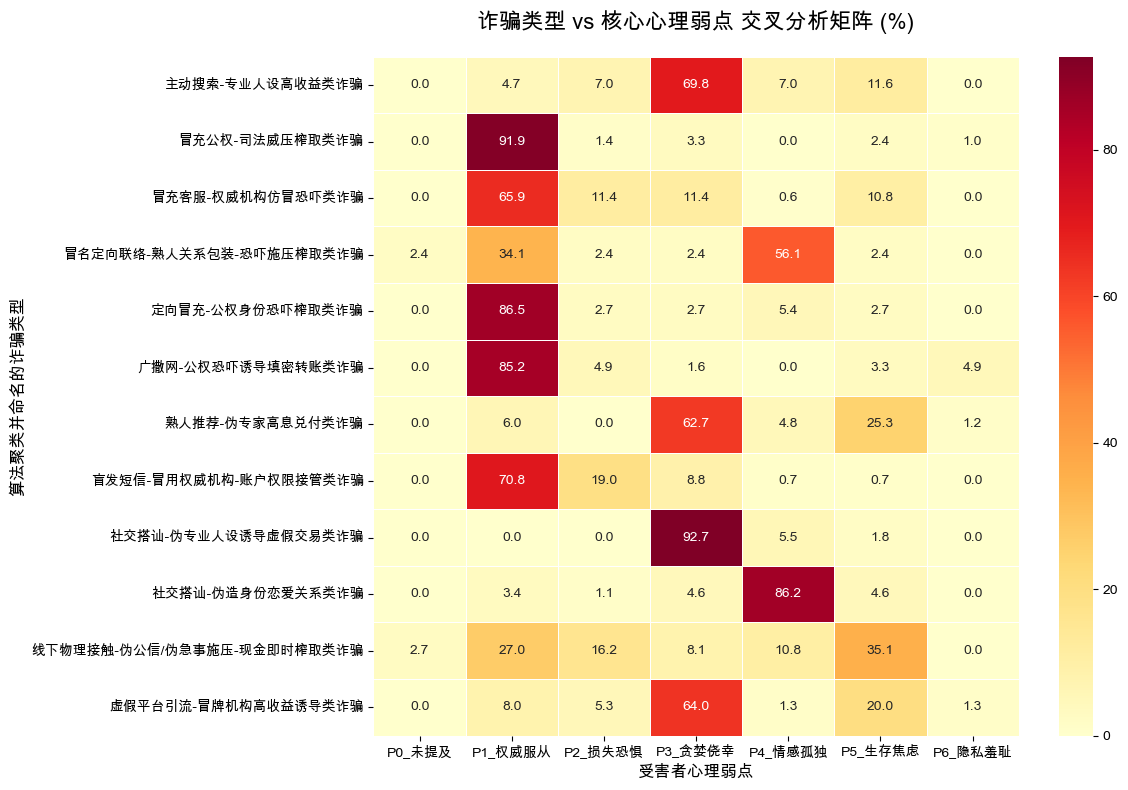

🎉 交叉热力图已生成并保存至：/Users/syx/Desktop/5508/clustering_results_bigram_cleaned/05_psychological_heatmap_new.png


In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib
import os

# 设置中文字体
matplotlib.rcParams["font.sans-serif"] = ["Arial Unicode MS", "SimHei"]
matplotlib.rcParams["axes.unicode_minus"] = False

# ================= 1. 读取数据 =================
# 读取包含了全部样本聚类结果的文件
FULL_DATA_FILE = "/Users/syx/Desktop/5508/clustering_results_bigram_cleaned/clustered_scam_only.xlsx"
# 读取刚才用大模型命名好的文件
NAMED_PROFILE_FILE = "/Users/syx/Desktop/5508/clustering_results_bigram_cleaned/cluster_profiles_named.xlsx"

df_full = pd.read_excel(FULL_DATA_FILE)
df_named = pd.read_excel(NAMED_PROFILE_FILE)

# ================= 2. 数据合并 =================
# 过滤掉噪声点（cluster = -1）
df_full = df_full[df_full['cluster'] != -1]

# 将大模型生成的名字 (cluster_name) 映射回全量数据
name_mapping = dict(zip(df_named['cluster_id'], df_named['cluster_name']))
df_full['诈骗类型名称'] = df_full['cluster'].map(name_mapping)

# 确保有心理弱点这一列，假设原表中叫 'psychological_vulnerability' (请根据实际列名修改)
PSY_COL = 'psychological_vulnerability' 

# ================= 3. 计算交叉矩阵 =================
# 用 pd.crosstab 计算诈骗类型和心理弱点的频次矩阵
cross_tab = pd.crosstab(df_full['诈骗类型名称'], df_full[PSY_COL])

# 将频次转换为行百分比 (即：在这类诈骗中，各心理弱点占百分之多少)
cross_tab_pct = cross_tab.div(cross_tab.sum(axis=1), axis=0) * 100

# ================= 4. 绘制热力图 =================
plt.figure(figsize=(12, 8))
sns.heatmap(cross_tab_pct, 
            annot=True,          # 在格子里显示数字
            fmt=".1f",           # 保留一位小数
            cmap="YlOrRd",       # 颜色主题：黄-橙-红 (越红代表关联越强)
            linewidths=.5)

plt.title("诈骗类型 vs 核心心理弱点 交叉分析矩阵 (%)", fontsize=16, pad=20)
plt.ylabel("算法聚类并命名的诈骗类型", fontsize=12)
plt.xlabel("受害者心理弱点", fontsize=12)

# 调整布局并保存
plt.tight_layout()
output_path = os.path.dirname(FULL_DATA_FILE) + "/05_psychological_heatmap_new.png"
plt.savefig(output_path, dpi=300)
plt.show()

print(f"🎉 交叉热力图已生成并保存至：{output_path}")

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib
import os

# ================= 1. 环境与中文字体配置 =================
for font in ["Arial Unicode MS", "SimHei", "PingFang SC", "Microsoft YaHei"]:
    try:
        matplotlib.rcParams["font.sans-serif"] = [font]
        break
    except:
        continue
matplotlib.rcParams["axes.unicode_minus"] = False

# ================= 2. 文件路径配置 =================
# 替换为你的实际工作目录
WORK_DIR = "/Users/syx/Desktop/5508/clustering_results_bigram_cleaned"
SCAM_DATA_FILE = os.path.join(WORK_DIR, "clustered_scam_only.xlsx")
NAMED_PROFILES_FILE = os.path.join(WORK_DIR, "cluster_profiles_named.xlsx")
OUTPUT_DIR = os.path.join(WORK_DIR, "named_visualizations")
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("📂 正在加载数据...")
df = pd.read_excel(SCAM_DATA_FILE)
df_names = pd.read_excel(NAMED_PROFILES_FILE)

# 建立 Cluster ID 到 名字 的映射字典
name_map = dict(zip(df_names['cluster_id'], df_names['cluster_name']))

# 获取有效的聚类 ID (排除 -1 噪声点)
valid_clusters = sorted([c for c in df['cluster'].unique() if c != -1])
cluster_labels_full = [f"C{cid}: {name_map.get(cid, '未命名')}" for cid in valid_clusters]

print(f"✅ 成功加载 {len(valid_clusters)} 个分类，开始生成可视化图表...")

# ================= 3. 生成带命名的 UMAP 散点图 =================
fig1, ax1 = plt.subplots(figsize=(16, 12))  # 画布放大，适应较长的名字

# 先画噪声点 (如果存在)
noise_df = df[df['cluster'] == -1]
if len(noise_df) > 0:
    ax1.scatter(noise_df['umap_x'], noise_df['umap_y'], c='lightgray', s=15, alpha=0.4, label='噪声点 (Outliers)')

# 为每个正常的 Cluster 分配颜色并作图
cmap = plt.cm.get_cmap("tab20", len(valid_clusters))
for i, cid in enumerate(valid_clusters):
    cmask = df['cluster'] == cid
    c_df = df[cmask]
    
    # 获取业务命名
    cname = name_map.get(cid, 'Unknown')
    legend_label = f"C{cid}: {cname} (n={len(c_df)})"
    
    # 画散点
    ax1.scatter(c_df['umap_x'], c_df['umap_y'], color=[cmap(i)], s=40, alpha=0.8, label=legend_label)
    
    # 核心亮点：在每个簇的中心位置打上标签文本，像地图一样！
    cx, cy = c_df['umap_x'].mean(), c_df['umap_y'].mean()
    ax1.annotate(f"C{cid}", (cx, cy), fontsize=10, weight='bold',
                 ha='center', va='center',
                 bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8))

ax1.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=10, title="诈骗分类 (大模型研判命名)", title_fontsize=12)
ax1.set_title("诈骗行为链路聚类宇宙图 (UMAP Semantic Space)", fontsize=18, pad=20)
ax1.set_xlabel("UMAP Dimension 1")
ax1.set_ylabel("UMAP Dimension 2")
plt.tight_layout()
fig1.savefig(os.path.join(OUTPUT_DIR, "01_Named_UMAP_Scatter.png"), dpi=300, bbox_inches="tight")
plt.close(fig1)
print("  💾 01_Named_UMAP_Scatter.png (UMAP散点图)")

# ================= 4. 生成带命名的特征分布热力图 (直观百分比) =================
# 提取用于统计的特征列
dims = ['prep_primary', 'contact_primary', 'trust_primary', 'manipulation_primary', 'operation_primary', 'extraction_primary']

# 收集所有非空且有效的标签
all_tags = set()
for d in dims:
    if d in df.columns:
        all_tags.update(df[d].dropna().unique())
all_tags = sorted([t for t in all_tags if "未" not in str(t) and "不适用" not in str(t) and str(t) != 'nan'])

# 构建百分比矩阵
matrix = np.zeros((len(valid_clusters), len(all_tags)))

for i, cid in enumerate(valid_clusters):
    c_df = df[df['cluster'] == cid]
    total_samples = len(c_df)
    
    tag_counts = {}
    for d in dims:
        if d in c_df.columns:
            for val in c_df[d]:
                if str(val) in all_tags:
                    tag_counts[str(val)] = tag_counts.get(str(val), 0) + 1
                    
    for j, tag in enumerate(all_tags):
        # 计算该动作在当前 Cluster 中的覆盖率 (百分比)
        matrix[i, j] = (tag_counts.get(tag, 0) / total_samples) * 100

# 清理全为 0 的空列，使图表更紧凑
used_cols = matrix.sum(axis=0) > 0
matrix_clean = matrix[:, used_cols]
tags_clean = [all_tags[j] for j in range(len(all_tags)) if used_cols[j]]

# 绘制热力图
fig2, ax2 = plt.subplots(figsize=(20, max(8, len(valid_clusters) * 0.8)))
sns.heatmap(
    matrix_clean, 
    xticklabels=tags_clean, 
    yticklabels=cluster_labels_full, # 核心：把纵轴变成了大模型起的名字
    cmap="Blues", 
    annot=True,     # 核心亮点：直接把百分比数字写在格子里
    fmt=".0f",      # 整数格式
    linewidths=0.5,
    cbar_kws={'label': '行为覆盖率 / 占比 (%)'}
)
ax2.set_title("各诈骗类型核心作案动作覆盖率热力图 (%)", fontsize=18, pad=20)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=11)
plt.tight_layout()
fig2.savefig(os.path.join(OUTPUT_DIR, "02_Named_Feature_Heatmap.png"), dpi=300, bbox_inches="tight")
plt.close(fig2)
print("  💾 02_Named_Feature_Heatmap.png (特征热力图)")

# ================= 5. 生成带命名的聚类规模柱状图 =================
fig3, ax3 = plt.subplots(figsize=(14, 8))
sizes = [len(df[df['cluster'] == cid]) for cid in valid_clusters]

bars = ax3.bar(
    cluster_labels_full, # 横坐标换成全名
    sizes, 
    color=[cmap(i) for i in range(len(valid_clusters))], 
    edgecolor="black", 
    linewidth=0.8
)

# 在柱子上打上数字
for bar, s in zip(bars, sizes):
    ax3.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
             str(s), ha="center", va="bottom", fontsize=11, fontweight='bold')

ax3.set_title("各类诈骗案件发案规模分布 (Cluster Sizes)", fontsize=16)
ax3.set_ylabel("案件数量 (样本数)", fontsize=12)
# 因为名字很长，倾斜横坐标
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.tight_layout()
fig3.savefig(os.path.join(OUTPUT_DIR, "03_Named_Cluster_Sizes.png"), dpi=300, bbox_inches="tight")
plt.close(fig3)
print("  💾 03_Named_Cluster_Sizes.png (案件规模图)")

print(f"\n🎉 完美！所有图表已重绘完毕并保存在: {OUTPUT_DIR}/")

📂 正在加载数据...
✅ 成功加载 12 个分类，开始生成可视化图表...
  💾 01_Named_UMAP_Scatter.png (UMAP散点图)
  💾 02_Named_Feature_Heatmap.png (特征热力图)
  💾 03_Named_Cluster_Sizes.png (案件规模图)

🎉 完美！所有图表已重绘完毕并保存在: /Users/syx/Desktop/5508/clustering_results_bigram_cleaned/named_visualizations/


In [4]:
import pandas as pd
import numpy as np
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier

# ================= 1. 加载数据 =================
INPUT_FILE = "/Users/syx/Desktop/5508/clustering_results_bigram_cleaned/clustered_scam_only.xlsx" # 请根据实际情况修改路径
NAMED_PROFILES_FILE = "cluster_profiles_named.xlsx"

print("📂 正在加载数据...")
df = pd.read_excel(INPUT_FILE)
df_names = pd.read_excel(NAMED_PROFILES_FILE)

# 剔除噪声 (-1) 和非聚类点 (-999)
df_clean = df[df['cluster'] >= 0].copy()

# 将数字类别替换为大模型起的名字
name_map = dict(zip(df_names['cluster_id'], df_names['cluster_name']))
df_clean['cluster_name'] = df_clean['cluster'].map(name_map)

# ================= 2. 特征工程 =================
y = df_clean['cluster_name']
feature_cols = ['prep_primary', 'contact_primary', 'trust_primary', 
                'manipulation_primary', 'operation_primary', 'extraction_primary']
df_features = df_clean[feature_cols].fillna('缺失')
X = pd.get_dummies(df_features)

print(f"✅ 数据准备完毕。参与评估的样本数: {len(X)}, 特征维度: {X.shape[1]}")

# ================= 3. 配置交叉验证 =================
print("\n🔄 正在启动 5-Fold 分层交叉验证 (Stratified 5-Fold CV)...")

# 配置随机森林模型
rf_model = RandomForestClassifier(
    n_estimators=100, 
    class_weight='balanced', 
    random_state=42, 
    n_jobs=-1
)

# 使用 StratifiedKFold (分层抽样)，确保每次抽出的测试卷里，各个诈骗类型的比例和总数据一致
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ================= 4. 执行评估并输出结果 =================
# 核心代码：让模型做 5 次互相独立的考试
scores = cross_val_score(rf_model, X, y, cv=cv_strategy, scoring='accuracy')

print("\n" + "="*50)
print("🎯 【模型稳定性评估报告】")
print("="*50)
print("每次交叉验证的具体得分 (Accuracy):")
for i, score in enumerate(scores):
    print(f"  第 {i+1} 折: {score * 100:.2f}%")

print("-" * 50)
# 计算平均分和波动区间 (2倍标准差包含约95%的置信区间)
mean_score = scores.mean() * 100
std_dev = scores.std() * 100

print(f"🌟 5-Fold 平均准确率: {mean_score:.2f}%")
print(f"📊 性能波动范围 (±2σ): ± {std_dev * 2:.2f}%")
print("="*50)
print("\n💡 答辩建议：您可以将上述【平均准确率】和【波动范围】直接放入 PPT 的模型评估页中。")

📂 正在加载数据...
✅ 数据准备完毕。参与评估的样本数: 1069, 特征维度: 42

🔄 正在启动 5-Fold 分层交叉验证 (Stratified 5-Fold CV)...

🎯 【模型稳定性评估报告】
每次交叉验证的具体得分 (Accuracy):
  第 1 折: 94.39%
  第 2 折: 93.93%
  第 3 折: 96.26%
  第 4 折: 90.19%
  第 5 折: 95.31%
--------------------------------------------------
🌟 5-Fold 平均准确率: 94.01%
📊 性能波动范围 (±2σ): ± 4.15%

💡 答辩建议：您可以将上述【平均准确率】和【波动范围】直接放入 PPT 的模型评估页中。


清洗后，真正参与模型训练的有效诈骗样本数: 1069

🌲 修正后的【决策树】分类报告:
              precision    recall  f1-score   support

           0       0.90      0.84      0.87        32
           1       0.91      1.00      0.95        10
           2       0.92      0.95      0.93        37
           3       0.92      1.00      0.96        12
           4       0.89      0.89      0.89        18
           5       0.58      0.78      0.67         9
           6       1.00      0.79      0.88        19
           7       1.00      0.91      0.95        22
           8       0.77      0.89      0.83        19
           9       1.00      1.00      1.00        17
          10       1.00      0.92      0.96        13
          11       1.00      1.00      1.00         6

    accuracy                           0.91       214
   macro avg       0.91      0.91      0.91       214
weighted avg       0.92      0.91      0.91       214


🌳 性能拉满的【随机森林】分类报告:
              precision    recall  f1-score   support

           0 

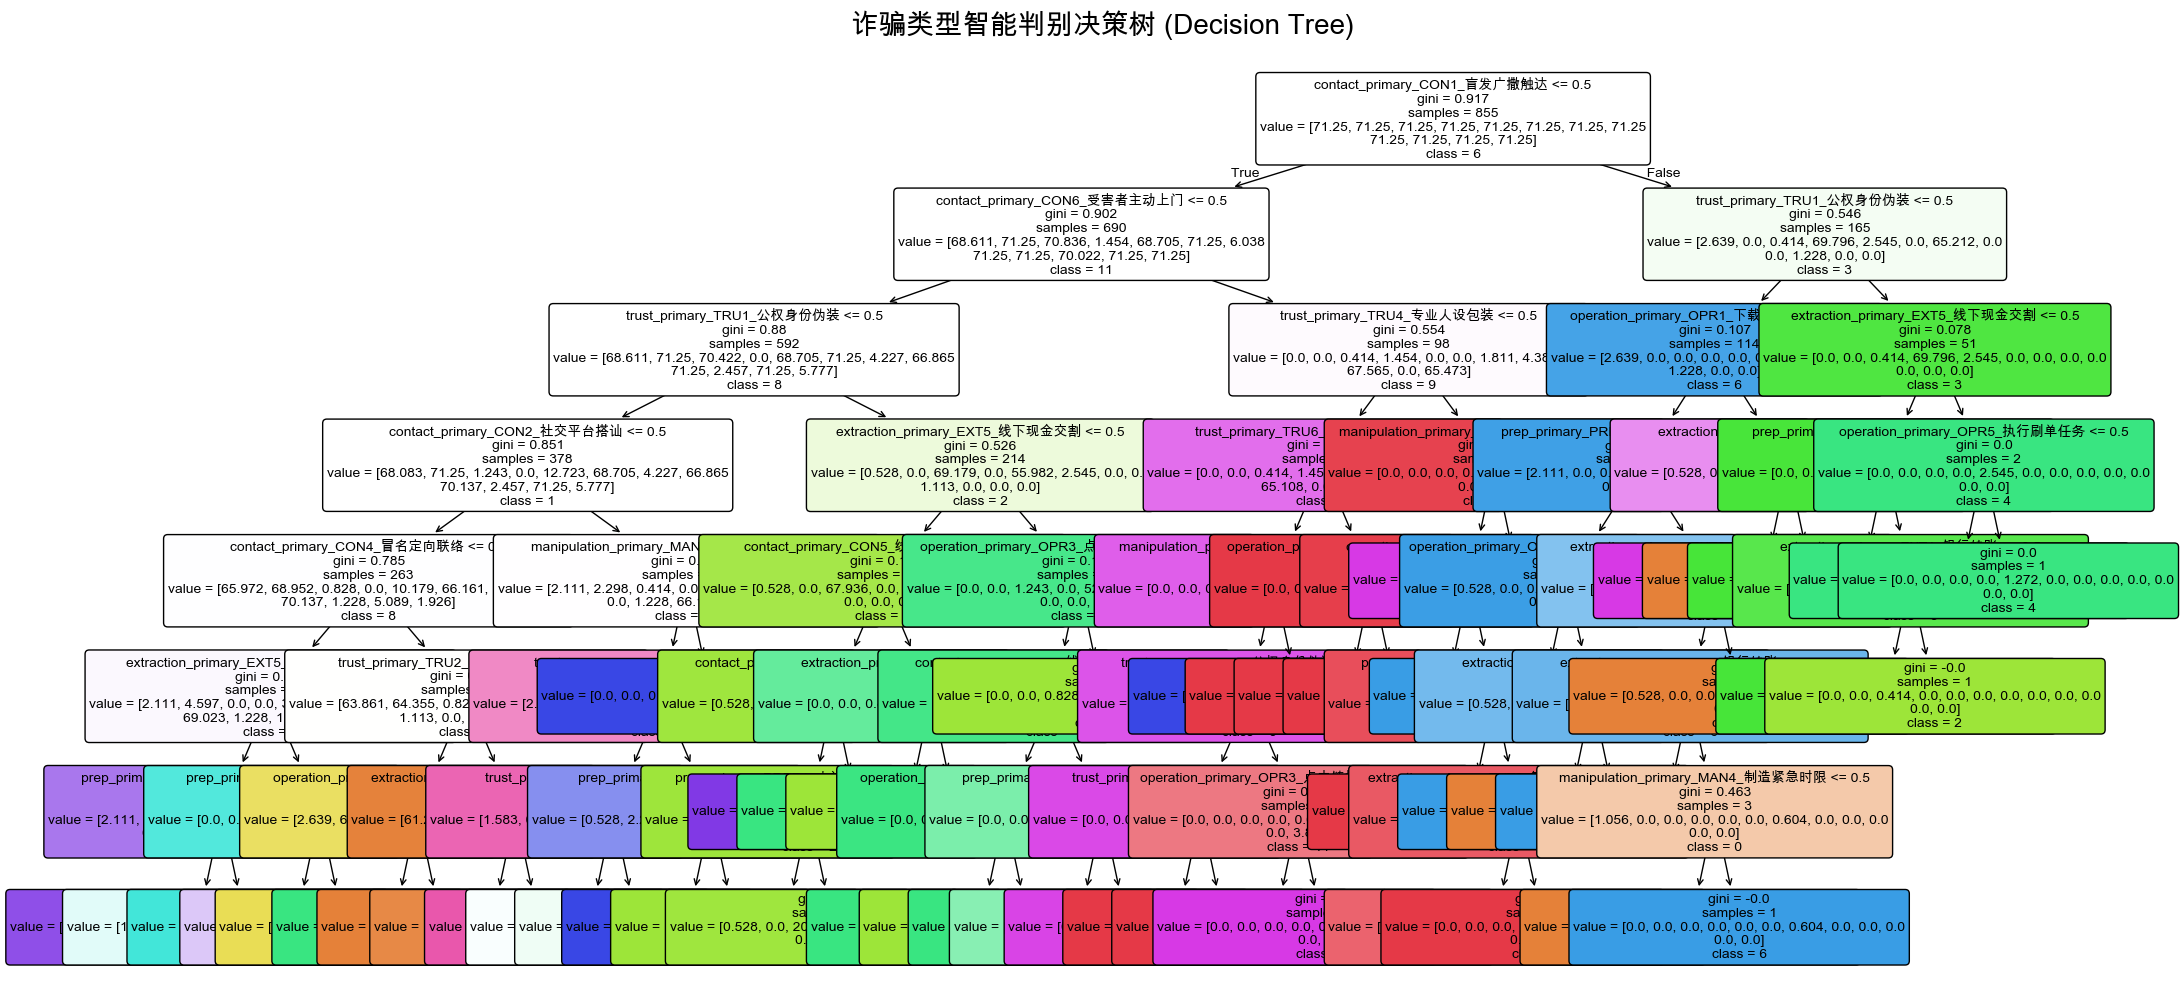

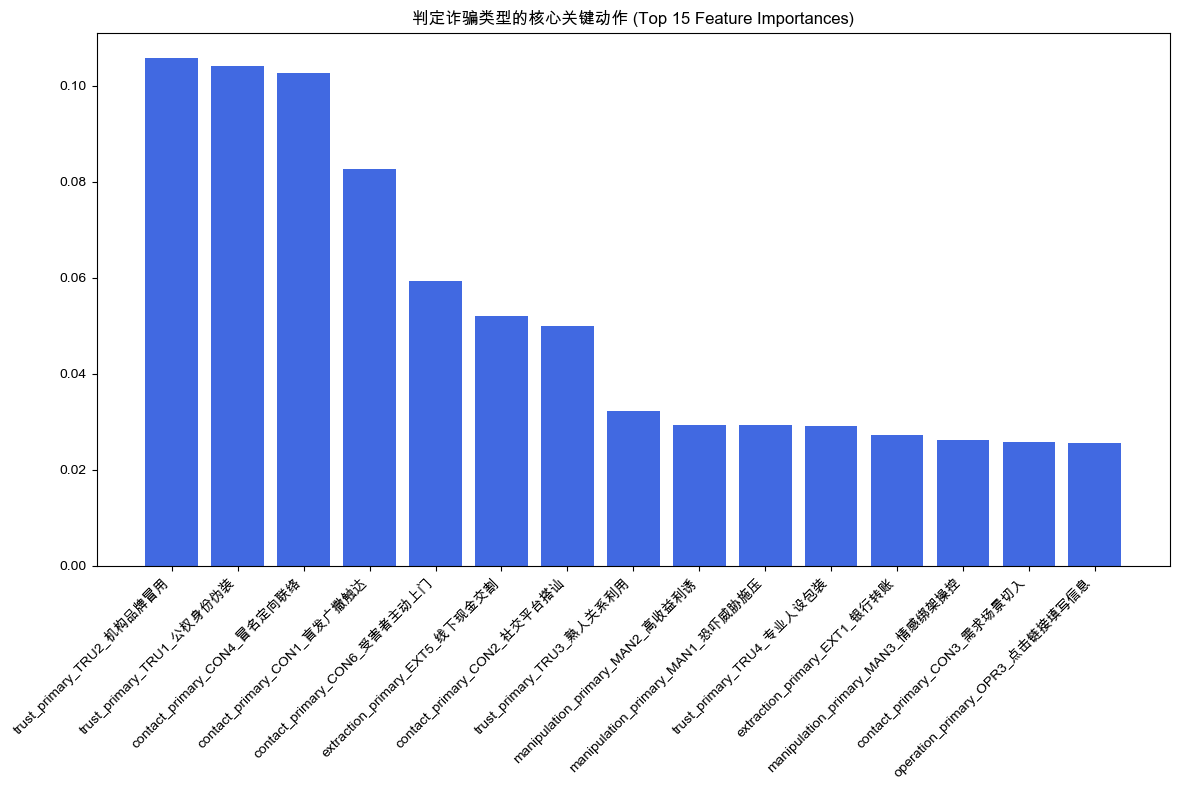

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# 解决中文字体显示问题
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'SimHei']
plt.rcParams['axes.unicode_minus'] = False

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# ================= 1. 加载与清洗数据 =================
INPUT_FILE = "/Users/syx/Desktop/5508/clustering_results_bigram_cleaned/clustered_scam_only.xlsx"
df = pd.read_excel(INPUT_FILE)

# 【核心修正 1】：只保留真正聚类成功的诈骗案件！剔除 -999（非聚类样本）和 -1（噪声点）
df_clean = df[df['cluster'] >= 0].copy()

print(f"清洗后，真正参与模型训练的有效诈骗样本数: {len(df_clean)}")

# ================= 2. 特征工程 =================
# 如果你有 cluster_name 列，这里最好用名字，这样画出的树更直观
y = df_clean['cluster'] 

feature_cols = ['prep_primary', 'contact_primary', 'trust_primary', 
                'manipulation_primary', 'operation_primary', 'extraction_primary']

df_features = df_clean[feature_cols].fillna('缺失')
X = pd.get_dummies(df_features)

# ================= 3. 模型训练 (决策树 vs 随机森林) =================
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 【核心修正 2】：加入 class_weight='balanced'，并加深树深
dt_model = DecisionTreeClassifier(max_depth=7, class_weight='balanced', random_state=42, criterion='gini')
dt_model.fit(X_train, y_train)

print("\n🌲 修正后的【决策树】分类报告:")
print(classification_report(y_test, dt_model.predict(X_test)))

# 顺便跑一个随机森林，看看你们提取的特征的“真实极限”在哪里
rf_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf_model.fit(X_train, y_train)

print("\n🌳 性能拉满的【随机森林】分类报告:")
print(classification_report(y_test, rf_model.predict(X_test)))

# ================= 4. 可视化决策树 (重头戏) =================
plt.figure(figsize=(24, 12))
plot_tree(dt_model, 
          feature_names=X.columns, 
          class_names=[str(c) for c in dt_model.classes_], # 如果 y 是名字，这里会显示名字
          filled=True, 
          rounded=True, 
          fontsize=10)
plt.title("诈骗类型智能判别决策树 (Decision Tree)", fontsize=20, pad=20)
plt.savefig("06_decision_tree_rules.png", dpi=300, bbox_inches='tight')
print("\n💾 决策树可视化已保存为: 06_decision_tree_rules.png")

# ================= 5. 进阶：随机森林特征重要性 =================
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1][:15] # 取前 15 个最重要特征

plt.figure(figsize=(12, 8))
plt.title("判定诈骗类型的核心关键动作 (Top 15 Feature Importances)")
plt.bar(range(15), importances[indices], align="center", color='royalblue')
plt.xticks(range(15), [X.columns[i] for i in indices], rotation=45, ha='right')
plt.tight_layout()
plt.savefig("07_feature_importance.png", dpi=300)
print("💾 特征重要性分析已保存为: 07_feature_importance.png")


🌲 中文版【决策树】分类报告:
                             precision    recall  f1-score   support

           主动搜索-专业人
设高收益类诈骗       1.00      0.83      0.91         6
            冒充公权-司法威
压榨取类诈骗       0.95      0.95      0.95        37
          冒充客服-权威机
构仿冒恐吓类诈骗       0.00      0.00      0.00        32
   冒名定向联络-熟
人关系包装-恐吓施压榨取类诈骗       0.26      1.00      0.41        10
          定向冒充-公权身
份恐吓榨取类诈骗       0.89      0.89      0.89        18
         广撒网-公权恐吓
诱导填密转账类诈骗       0.92      1.00      0.96        12
           熟人推荐-伪专家
高息兑付类诈骗       0.61      1.00      0.76        19
     盲发短信-冒用权
威机构-账户权限接管类诈骗       1.00      0.89      0.94        19
       社交搭讪-伪专业
人设诱导虚假交易类诈骗       0.87      1.00      0.93        13
          社交搭讪-伪造身
份恋爱关系类诈骗       1.00      0.91      0.95        22
线下物理接触-伪
公信/伪急事施压-现金即时榨取类诈骗       0.00      0.00      0.00         9
       虚假平台引流-冒
牌机构高收益诱导类诈骗       0.94      1.00      0.97        17

                   accuracy                           0.77       214
               

/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.




✨ 极简清爽版决策树已保存为: 06_Named_Decision_Tree_Clean.png


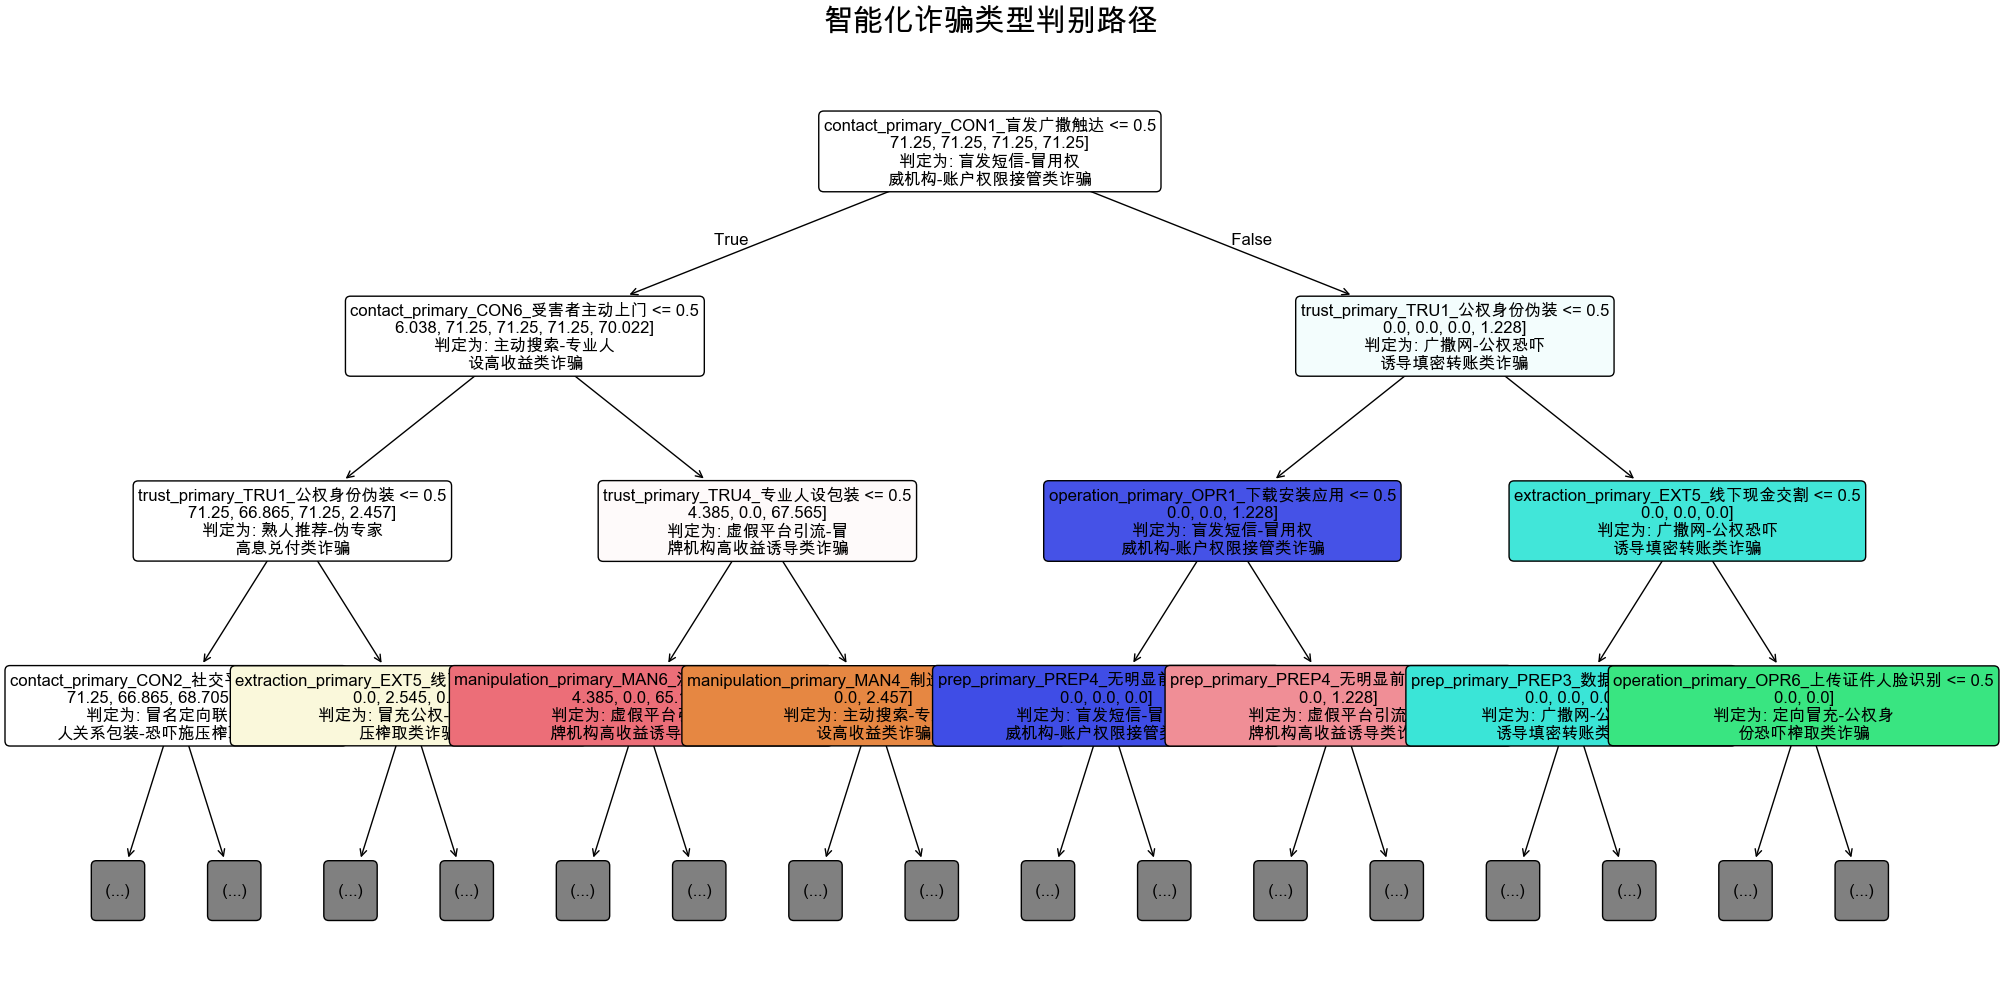

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report

# 解决中文字体显示问题
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'SimHei']
plt.rcParams['axes.unicode_minus'] = False

# ================= 1. 加载数据 =================
INPUT_FILE = "/Users/syx/Desktop/5508/clustering_results_bigram_cleaned/clustered_scam_only.xlsx"
df = pd.read_excel(INPUT_FILE)

# 【重点】加载大模型命名好的文件
NAMED_PROFILES_FILE = "/Users/syx/Desktop/5508/clustering_results_bigram_cleaned/cluster_profiles_named.xlsx"
df_names = pd.read_excel(NAMED_PROFILES_FILE)

# 剔除噪声点 (-1) 和未聚类点 (-999)
df_clean = df[df['cluster'] >= 0].copy()

# ================= 2. 将数字类别替换为中文命名 =================
# 构建映射字典 {0: '名字A', 1: '名字B'...}
name_map = dict(zip(df_names['cluster_id'], df_names['cluster_name']))
# 让过长的名字在第8个字符处自动换行，保持框框清爽
def wrap_text(text, width=8):
    if len(str(text)) > width:
       return str(text)[:width] + '\n' + str(text)[width:]
    return str(text)
#df_clean['cluster_name'] = df_clean['cluster'].map(name_map)
df_clean['cluster_name'] = df_clean['cluster'].map(name_map).apply(wrap_text)

# ================= 3. 特征工程 =================
# 【核心改变】：将 y 设定为刚刚映射好的中文名字！
y = df_clean['cluster_name'] 

feature_cols = ['prep_primary', 'contact_primary', 'trust_primary', 
                'manipulation_primary', 'operation_primary', 'extraction_primary']
df_features = df_clean[feature_cols].fillna('缺失')
X = pd.get_dummies(df_features)

# ================= 4. 模型训练 =================
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 使用 class_weight='balanced' 处理样本不平衡，限制深度保持清爽
dt_model = DecisionTreeClassifier(max_depth=5, class_weight='balanced', random_state=42, criterion='gini')
dt_model.fit(X_train, y_train)

print("\n🌲 中文版【决策树】分类报告:")
print(classification_report(y_test, dt_model.predict(X_test)))

# ================= 5. 可视化带名字的决策树 =================
# ================= 5. 可视化终极清爽版决策树 =================
plt.figure(figsize=(24, 12))

# 1. 生成原始的树图对象
annotations = plot_tree(dt_model, 
                        max_depth=3,  # 只看前3层
                        feature_names=X.columns, 
                        class_names=list(dt_model.classes_), 
                        filled=True, 
                        rounded=True, 
                        fontsize=12) # 字体稍微放大点

# 2. 【核心去杂乱代码】遍历树中的每一个文本框，剔除没用的数学指标
for ann in annotations:
    text = ann.get_text()
    if text:
        # 按换行符切分文本
        lines = text.split('\n')
        # 我们只保留不以 'gini', 'samples', 'value' 开头的行
        # 通常这就只剩下了 "判断条件" 和 "class=..."
        clean_lines = [line for line in lines if not line.startswith(('gini', 'samples', 'value'))]
        
        # 把 class= 的前缀也去掉，直接显示中文名，更清爽
        clean_lines = [line.replace('class = ', '判定为: ') for line in clean_lines]
        
        # 重新把干净的文本塞回框里
        ann.set_text('\n'.join(clean_lines))

plt.title("智能化诈骗类型判别路径", fontsize=22, pad=20, fontweight='bold')
plt.savefig("06_Named_Decision_Tree_Clean.png", dpi=300, bbox_inches='tight')
print("\n✨ 极简清爽版决策树已保存为: 06_Named_Decision_Tree_Clean.png")

In [8]:
from sklearn.tree import export_text

# 提取完整的决策树文本规则 (max_depth 设为你实际的树深，比如 7)
tree_rules = export_text(dt_model, feature_names=list(X.columns), max_depth=7)

# 把规则保存为文本文件
with open("08_Full_Decision_Rules.txt", "w", encoding="utf-8") as f:
    f.write(tree_rules)

print("📝 完整的文本版判定规则已保存为: 08_Full_Decision_Rules.txt")

📝 完整的文本版判定规则已保存为: 08_Full_Decision_Rules.txt


参与训练的样本数: 1069, 特征维度: 42

🌳 【随机森林】测试集分类报告 (极限性能表现):
                    precision    recall  f1-score   support

   主动搜索-专业人设高收益类诈骗       1.00      1.00      1.00         6
    冒充公权-司法威压榨取类诈骗       0.92      0.95      0.93        37
冒充客服-权威机构仿冒恐吓类诈...       0.94      0.97      0.95        32
冒名定向联络-熟人关系包装-恐...       1.00      1.00      1.00        10
定向冒充-公权身份恐吓榨取类诈...       0.94      0.89      0.91        18
广撒网-公权恐吓诱导填密转账类...       0.92      1.00      0.96        12
   熟人推荐-伪专家高息兑付类诈骗       0.95      1.00      0.97        19
盲发短信-冒用权威机构-账户权...       1.00      0.89      0.94        19
社交搭讪-伪专业人设诱导虚假交...       1.00      0.92      0.96        13
社交搭讪-伪造身份恋爱关系类诈...       0.96      1.00      0.98        22
线下物理接触-伪公信/伪急事施...       1.00      0.89      0.94         9
虚假平台引流-冒牌机构高收益诱...       1.00      1.00      1.00        17

          accuracy                           0.96       214
         macro avg       0.97      0.96      0.96       214
      weighted avg       0.96      0.96      0

/var/folders/9q/ywtdr2kx78d4gg56pbn1dk_w0000gn/T/ipykernel_69374/1072166580.py:73: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.





💾 随机森林特征重要性图表已保存为: 07_Named_Feature_Importance.png


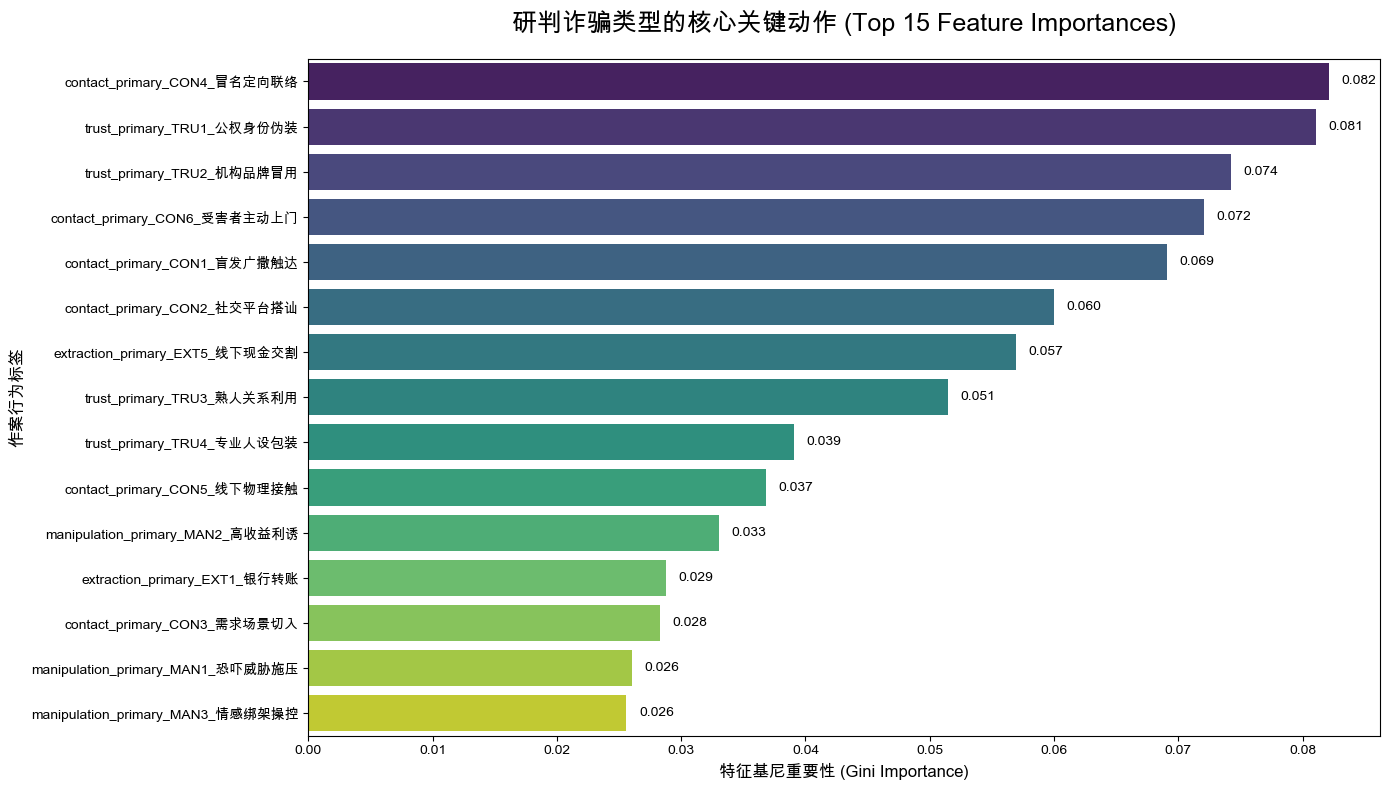

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
import seaborn as sns
import matplotlib

# ================= 1. 环境与中文字体配置 =================
for font in ["Arial Unicode MS", "SimHei", "PingFang SC", "Microsoft YaHei"]:
    try:
        matplotlib.rcParams["font.sans-serif"] = [font]
        break
    except:
        continue
matplotlib.rcParams["axes.unicode_minus"] = False

# ================= 2. 加载数据与预处理 =================
INPUT_FILE = "/Users/syx/Desktop/5508/clustering_results_bigram_cleaned/clustered_scam_only.xlsx"
NAMED_PROFILES_FILE = "/Users/syx/Desktop/5508/clustering_results_bigram_cleaned/cluster_profiles_named.xlsx"

df = pd.read_excel(INPUT_FILE)
df_names = pd.read_excel(NAMED_PROFILES_FILE)

# 剔除噪声 (-1) 和非聚类点 (-999)
df_clean = df[df['cluster'] >= 0].copy()

# 将数字类别替换为大模型起的名字
name_map = dict(zip(df_names['cluster_id'], df_names['cluster_name']))

# 截断太长的名字，防止分类报告排版错乱
def shorten_name(name):
    name_str = str(name)
    return name_str[:15] + "..." if len(name_str) > 15 else name_str

df_clean['cluster_name'] = df_clean['cluster'].map(name_map).apply(shorten_name)

# ================= 3. 特征工程 =================
y = df_clean['cluster_name']
feature_cols = ['prep_primary', 'contact_primary', 'trust_primary', 
                'manipulation_primary', 'operation_primary', 'extraction_primary']
df_features = df_clean[feature_cols].fillna('缺失')
X = pd.get_dummies(df_features)

print(f"参与训练的样本数: {len(X)}, 特征维度: {X.shape[1]}")

# 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ================= 4. 训练随机森林 =================
# n_estimators=100 表示种100棵树; class_weight='balanced' 解决类别不平衡问题
rf_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

print("\n🌳 【随机森林】测试集分类报告 (极限性能表现):")
print(classification_report(y_test, rf_model.predict(X_test)))

# ================= 5. 可视化：特征重要性 (核心交付物) =================
# 获取每列特征的权重贡献度
importances = rf_model.feature_importances_
feature_names = X.columns

# 将特征和权重打包，按权重从大到小排序
feature_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_imp_df = feature_imp_df.sort_values(by='Importance', ascending=False)

# 取前 15 个最具决定性的特征来画图
top_n = 15
top_features = feature_imp_df.head(top_n)

plt.figure(figsize=(14, 8))
sns.barplot(x='Importance', y='Feature', data=top_features, palette='viridis')

plt.title("研判诈骗类型的核心关键动作 (Top 15 Feature Importances)", fontsize=18, pad=20)
plt.xlabel("特征基尼重要性 (Gini Importance)", fontsize=12)
plt.ylabel("作案行为标签", fontsize=12)

# 在柱子旁边打上具体数值
for index, value in enumerate(top_features['Importance']):
    plt.text(value + 0.001, index, f'{value:.3f}', va='center', fontsize=10)

plt.tight_layout()
plt.savefig("07_Named_Feature_Importance.png", dpi=300)
print("\n💾 随机森林特征重要性图表已保存为: 07_Named_Feature_Importance.png")

In [23]:
import joblib

# 保存模型文件
joblib.dump(rf_model, 'fraud_rf_model.pkl')
# 把特征的列名也保存下来，网页预测时需要对齐维度！
joblib.dump(list(X.columns), 'model_features.pkl') 
print("✅ 模型和特征列已保存，准备接入网页！")

✅ 模型和特征列已保存，准备接入网页！


In [10]:
%pip install -U kaleido

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [kaleido]
Note: you may need to restart the kernel to use updated packages.


In [13]:
import pandas as pd
import plotly.express as px

# 1. 加载数据
df_full = pd.read_excel("/Users/syx/Desktop/5508/clustering_results_bigram_cleaned/clustered_scam_only.xlsx")
df_clean = df_full[df_full['cluster'] >= 0].copy()

# 2. 提取核心的流转阶段
flow_cols = ['contact_primary', 'trust_primary', 'manipulation_primary', 'extraction_primary']
df_flow = df_clean[flow_cols].copy()

# 3. 清洗前缀
for col in flow_cols:
    df_flow[col] = df_flow[col].apply(lambda x: str(x).split('_')[-1] if '_' in str(x) else str(x))

# 4. 只保留 Top 20 主流链路
path_counts = df_flow.value_counts().reset_index(name='案件数')
top_paths = path_counts.head(20)

# 5. 画图
fig_flow = px.parallel_categories(
    top_paths, 
    dimensions=flow_cols,
    color='案件数',
    labels={'contact_primary': '接触阶段', 'trust_primary': '信任阶段', 'manipulation_primary': '操纵阶段', 'extraction_primary': '榨取阶段'},
    color_continuous_scale=px.colors.sequential.Agsunset 
)

# 🌟 新增：添加高大上的标题和调整字体布局
fig_flow.update_layout(
    title={
        'text': "🔍 诈骗犯罪主流行为全链路流转图 (Top 20 MO Flows)",
        'y': 0.95,
        'x': 0.5,
        'xanchor': 'center',
        'yanchor': 'top',
        'font': dict(size=28, color="#1E3A8A", family="Arial") # 深蓝色大标题
    },
    font=dict(size=14), # 坐标轴标签字体
    margin=dict(l=50, r=50, t=100, b=50) # 顶部留出更多空间给标题
)

# 6. 保存为超高清图片
fig_flow.write_image("08_MO_Sankey_Flow_HighRes_Titled.png", width=1400, height=750, scale=3)
print("✅ 带标题的超高清全链路桑基图已保存为：08_MO_Sankey_Flow_HighRes_Titled.png")

✅ 带标题的超高清全链路桑基图已保存为：08_MO_Sankey_Flow_HighRes_Titled.png


In [14]:
import pandas as pd
import plotly.express as px

# 1. 加载数据
df_full = pd.read_excel("clustered_full_data.xlsx")
df_names = pd.read_excel("cluster_profiles_named.xlsx")

# 2. 剔除噪声点，保留有效案卷
df_clean = df_full[df_full['cluster'] >= 0].copy()

# 3. 映射中文命名
name_map = dict(zip(df_names['cluster_id'], df_names['cluster_name']))
df_clean['cluster_name'] = df_clean['cluster'].map(name_map)

# 4. 计算交叉矩阵
# 这里使用 normalize='index' * 100，计算的是横向的百分比，与你的心理弱点图（Figure B5）保持一致
cross_driver = pd.crosstab(df_clean['cluster_name'], df_clean['compliance_driver'], normalize='index') * 100
cross_driver = cross_driver.round(1) # 保留一位小数

# 5. 使用 Plotly 绘制橙色系热力图
fig_driver = px.imshow(
    cross_driver,
    labels=dict(x="受害者顺从驱动力 (Compliance Driver)", y="算法聚类并命名的诈骗类型", color="占比 (%)"),
    x=cross_driver.columns,
    y=cross_driver.index,
    color_continuous_scale="Oranges", # 使用橙色渐变，展现出警示感，并与心理弱点的蓝色/红色区分
    text_auto=True,
    aspect="auto"
)

# 6. 设置高大上的标题和调整边距布局
fig_driver.update_layout(
    title={
        'text': "诈骗类型 vs 核心顺从驱动力 交叉分析矩阵 (%)",
        'y': 0.95,
        'x': 0.5,
        'xanchor': 'center',
        'yanchor': 'top',
        'font': dict(size=24, color="#1E3A8A", family="Arial") # 深蓝色大标题
    },
    xaxis_tickangle=-15, # 稍微倾斜下方标签，防止拥挤
    font=dict(size=14),
    margin=dict(l=350, r=50, t=100, b=80) # 左侧留足350的宽度，绝对不会把超长名字切断
)

# 7. 导出超高清静态图片
fig_driver.write_image("09_Compliance_Driver_Heatmap_HighRes.png", width=1600, height=900, scale=3)
print("✅ 超高清顺从驱动力交叉矩阵图已保存为：09_Compliance_Driver_Heatmap_HighRes.png")

✅ 超高清顺从驱动力交叉矩阵图已保存为：09_Compliance_Driver_Heatmap_HighRes.png
